# 🚢 Titanic Survival Prediction — ML Capstone Project

**Goal:** Predict whether a passenger survived the Titanic disaster using their details (class, sex, age, family, fare, port).

**Type of problem:** Supervised learning → *binary classification* (`Survived`: 0 = No, 1 = Yes)

**Workflow followed in this notebook**

| Step | What we do |
|---|---|
| 1. Problem understanding | Define target, features and success metric |
| 2. Data loading & inspection | Shape, types, missing values |
| 3. EDA | Find which factors affect survival |
| 4. Feature engineering | Create `Title`, `FamilySize`, `IsAlone` |
| 5. Preprocessing | Impute, scale, one-hot encode using a `Pipeline` (no data leakage) |
| 6. Modeling | Train 5 algorithms, compare with 5-fold cross-validation |
| 7. Tuning | `GridSearchCV` on the best candidates |
| 8. Evaluation | Accuracy, precision/recall/F1, confusion matrix, ROC-AUC |
| 9. Interpretation | Feature importance |
| 10. Deployment | Save model → Streamlit app (`app.py`) |

**Metric:** Accuracy is the main metric (the classes are fairly balanced: ~62% / 38%), supported by precision, recall, F1 and ROC-AUC.

## 1. Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

The data is the classic Kaggle Titanic `train.csv` (891 passengers, 12 columns).
Put `train.csv` inside the `data/` folder. If it is missing, the cell below downloads a copy automatically (useful on Google Colab).

In [2]:
import os
DATA_PATH = "../data/train.csv" if os.path.exists("../data/train.csv") else "data/train.csv"
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(DATA_PATH if os.path.exists(DATA_PATH) else URL)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Information

In [3]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Column meaning**

- `Survived` – target (0/1) · `Pclass` – ticket class (1 = upper, 3 = lower) · `Sex`, `Age`
- `SibSp` – siblings/spouses aboard · `Parch` – parents/children aboard
- `Fare` – ticket price · `Embarked` – port (S, C, Q) · `Cabin`, `Ticket`, `Name`, `PassengerId` – identifiers/text

## 4. Missing Values

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

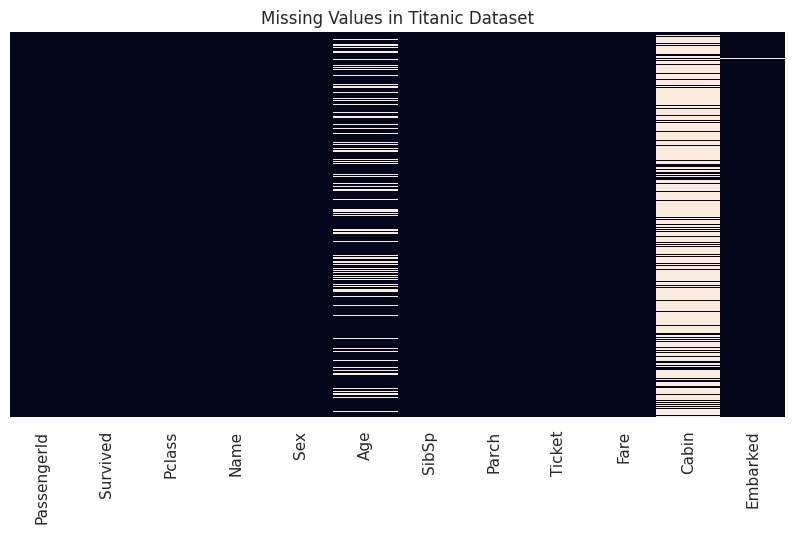

In [6]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values in Titanic Dataset")
plt.show()

**Observations & decisions**

- `Age` has 177 missing values (~20%) → **fill with the median** (robust to outliers).
- `Embarked` has 2 missing values → **fill with the most frequent value**.
- `Cabin` is missing for 687 rows (~77%) → too sparse, so we **drop it**.
- All imputation is done *inside the pipeline* and fitted on training data only, which prevents data leakage.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target distribution

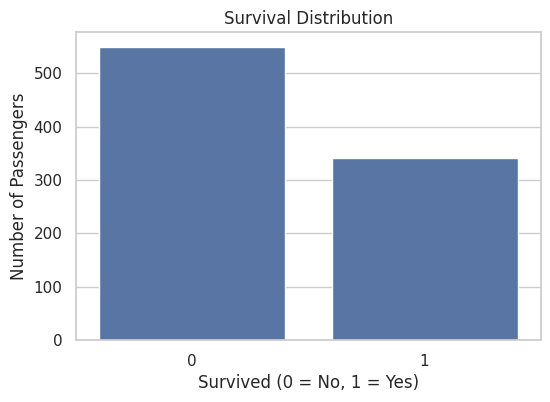

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()
print(df["Survived"].value_counts(normalize=True).round(3))

Only **38.4%** survived. The classes are moderately imbalanced, so accuracy is acceptable but we also check recall and F1.

### 5.2 Gender vs Survival

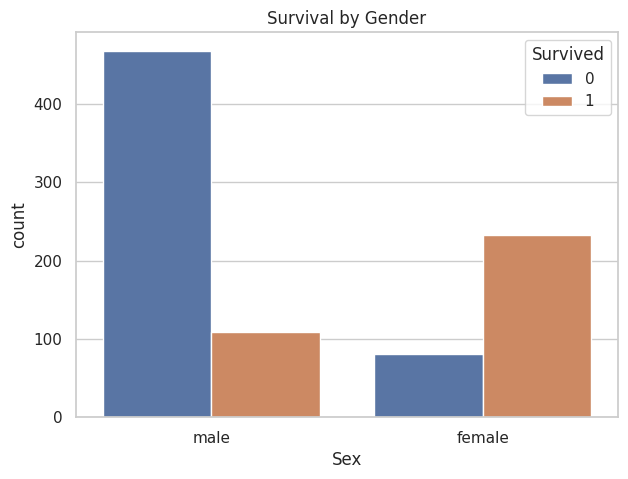

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()
print(df.groupby("Sex")["Survived"].mean().round(3))

**Women survived at 74%, men at only 19%.** This is the strongest single factor (“women and children first”).

### 5.3 Passenger class vs Survival

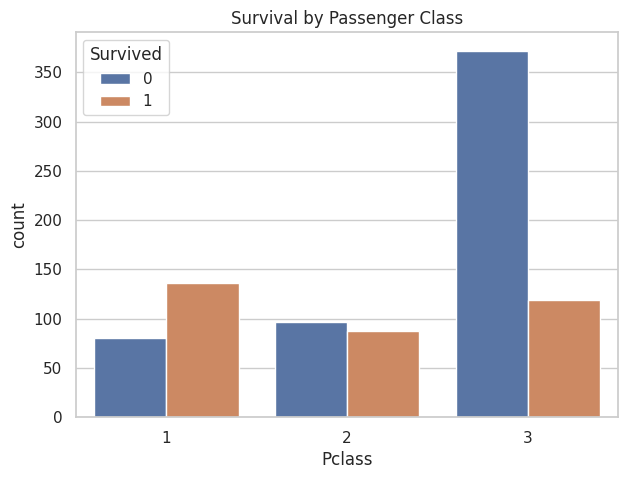

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()
print(df.groupby("Pclass")["Survived"].mean().round(3))

Survival drops with class: **63% (1st) → 47% (2nd) → 24% (3rd)**. Wealth/position on the ship mattered.

### 5.4 Age distribution

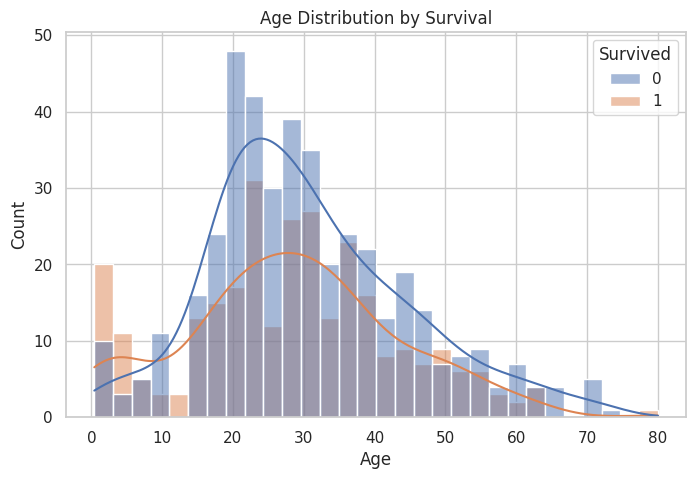

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.show()

Children (under ~12) had the highest survival rate (~58%); passengers over 60 had the lowest (~23%).

### 5.5 Fare vs Survival

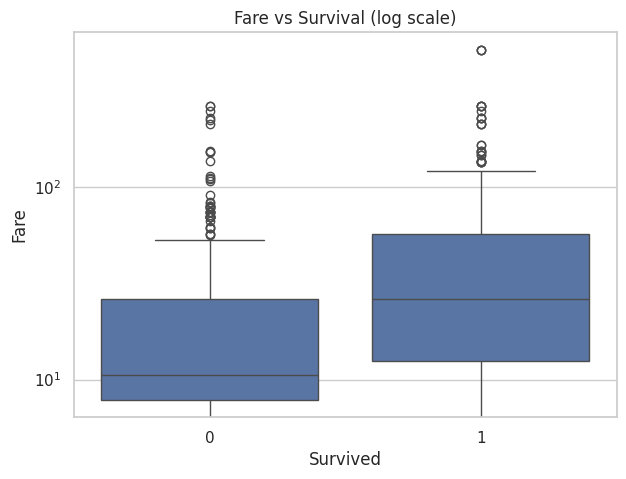

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64


In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Survived", y="Fare", data=df)
plt.yscale("log")
plt.title("Fare vs Survival (log scale)")
plt.show()
print(df.groupby("Survived")["Fare"].median())

Survivors paid a higher fare (median £26 vs £10.5). Fare is skewed, so a log scale is used for the plot. (A box plot is used instead of a line plot because `Survived` is categorical.)

### 5.6 Correlation heatmap

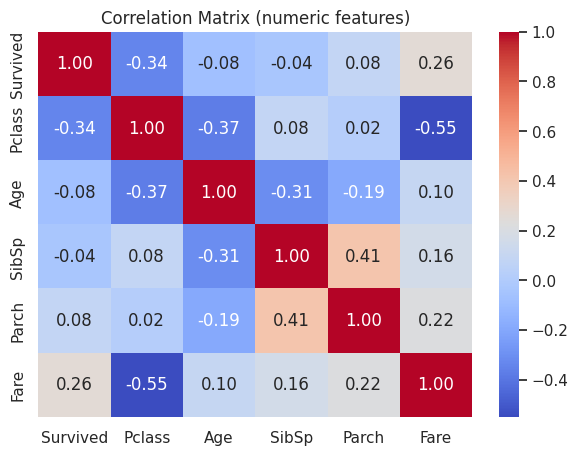

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (numeric features)")
plt.show()

`Pclass` (−0.34) and `Fare` (+0.26) have the strongest linear relation with survival.

## 6. Feature Engineering

Raw columns hide useful information, so we create three new features:

| New feature | How | Why |
|---|---|---|
| `Title` | Extracted from `Name` (Mr, Mrs, Miss, Master, Rare) | Captures sex + age + social status together |
| `FamilySize` | `SibSp + Parch + 1` | Family size affects survival (small families did best) |
| `IsAlone` | `FamilySize == 1` | Lone travellers survived less (30%) |

In [13]:
def add_features(data):
    data = data.copy()
    data["Title"] = data["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    data["Title"] = data["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    data["Title"] = data["Title"].where(data["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    return data

df = add_features(df)
df[["Name", "Title", "FamilySize", "IsAlone"]].head()

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


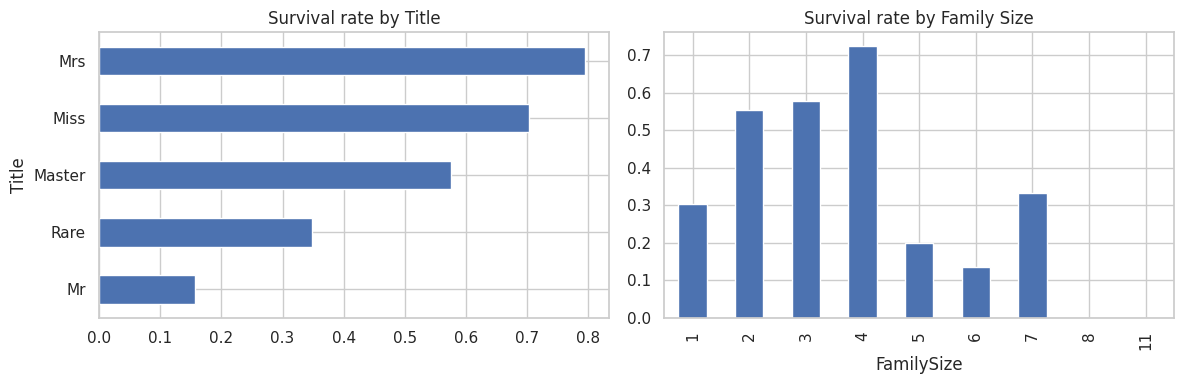

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("Title")["Survived"].mean().sort_values().plot(kind="barh", ax=ax[0], title="Survival rate by Title")
df.groupby("FamilySize")["Survived"].mean().plot(kind="bar", ax=ax[1], title="Survival rate by Family Size")
plt.tight_layout()
plt.show()

## 7. Feature Selection & Train/Test Split

We drop identifiers and sparse columns (`PassengerId`, `Name`, `Ticket`, `Cabin`) and keep 8 features.
An 80/20 **stratified** split keeps the same survival ratio in both sets. The test set is only used at the very end.

In [15]:
numeric_features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title"]

X = df[numeric_features + categorical_features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (712, 8)
Testing data : (179, 8)


## 8. Preprocessing Pipeline

- **Numeric:** median imputation → `StandardScaler` (needed by KNN / Logistic Regression)
- **Categorical:** most-frequent imputation → `OneHotEncoder`
- Both are combined with `ColumnTransformer`. Wrapping everything in a `Pipeline` means the exact same steps run automatically for new data (and in the web app).

In [16]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## 9. Modeling — Compare 5 Algorithms

A single train/test split on only 179 test rows is noisy (one lucky split can change accuracy by 2–3%).
So we compare models using **5-fold stratified cross-validation on the training set** (the fair way), and also show the test accuracy for reference.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes":         GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}

for name, model in models.items():
    pipe = Pipeline([("preprocessing", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    rows.append({
        "Model": name,
        "CV Accuracy (mean)": scores.mean(),
        "CV Std": scores.std(),
        "Test Accuracy": accuracy_score(y_test, pipe.predict(X_test)),
    })

results = pd.DataFrame(rows).sort_values("CV Accuracy (mean)", ascending=False).reset_index(drop=True)
results.round(3)

,Model,CV Accuracy (mean),CV Std,Test Accuracy
0,Logistic Regression,0.823,0.019,0.838
1,KNN,0.803,0.022,0.816
2,Decision Tree,0.803,0.013,0.799
3,Naive Bayes,0.792,0.024,0.788
4,Random Forest,0.792,0.012,0.799


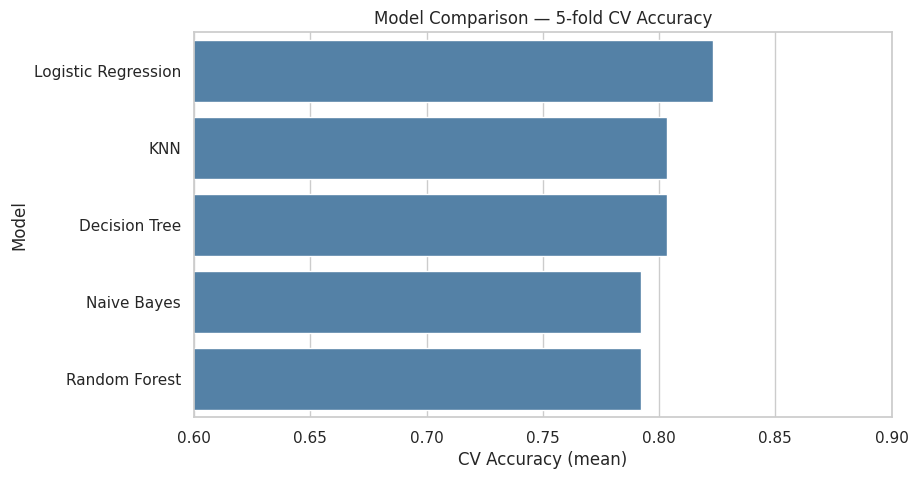

In [18]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="CV Accuracy (mean)", y="Model", color="steelblue")
plt.xlim(0.6, 0.9)
plt.title("Model Comparison — 5-fold CV Accuracy")
plt.show()

## 10. Hyperparameter Tuning (GridSearchCV)

We tune the two most promising model families — **Logistic Regression** and **Random Forest** — with 5-fold CV inside `GridSearchCV`, then pick the winner by **cross-validation score** (not by the test set).

In [19]:
grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        {"model__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200, 300],
         "model__max_depth": [3, 5, 7, None],
         "model__min_samples_split": [2, 5, 10]},
    ),
}

searches = {}
for name, (model, grid) in grids.items():
    pipe = Pipeline([("preprocessing", preprocessor), ("model", model)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name:20s} best CV acc = {gs.best_score_:.3f}   params = {gs.best_params_}")

best_name = max(searches, key=lambda n: searches[n].best_score_)
best_model = searches[best_name].best_estimator_
print("\n✅ Selected model:", best_name)

Logistic Regression  best CV acc = 0.823   params = {'model__C': 10}


Random Forest        best CV acc = 0.829   params = {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}

✅ Selected model: Random Forest


## 11. Final Evaluation on the Test Set

The test set has not been used for any decision so far, so this is an honest estimate of real-world performance.

In [20]:
final_pred = best_model.predict(X_test)
final_proba = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, final_pred)
test_auc = roc_auc_score(y_test, final_proba)
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Test ROC-AUC : {test_auc:.3f}\n")
print(classification_report(y_test, final_pred, target_names=["Did Not Survive", "Survived"]))

Test Accuracy: 0.827
Test ROC-AUC : 0.858

                 precision    recall  f1-score   support

Did Not Survive       0.84      0.89      0.86       110
       Survived       0.81      0.72      0.76        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.81       179
   weighted avg       0.83      0.83      0.82       179



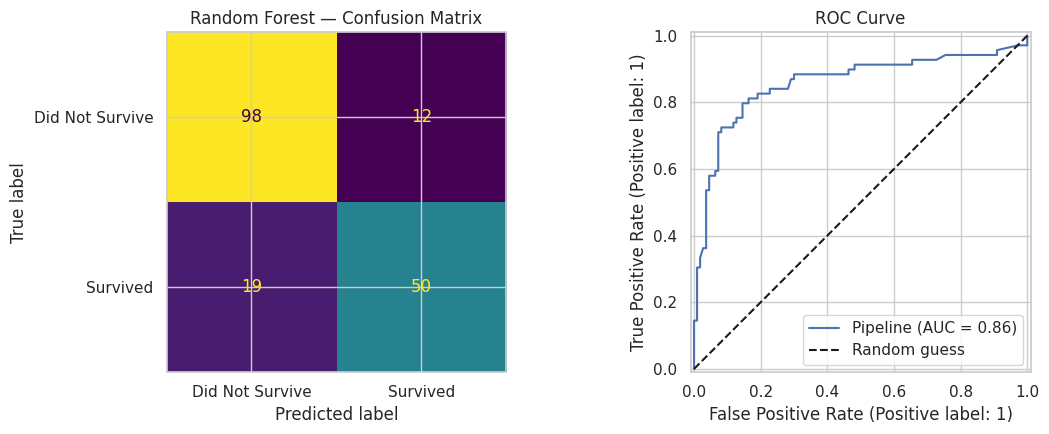

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, final_pred),
                       display_labels=["Did Not Survive", "Survived"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title(f"{best_name} — Confusion Matrix")
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", label="Random guess")
ax[1].set_title("ROC Curve")
ax[1].legend()
plt.tight_layout()
plt.show()

## 12. Feature Importance (Model Interpretation)

**Permutation importance** shuffles one feature at a time and measures how much accuracy drops — a bigger drop means the model relies on that feature more.

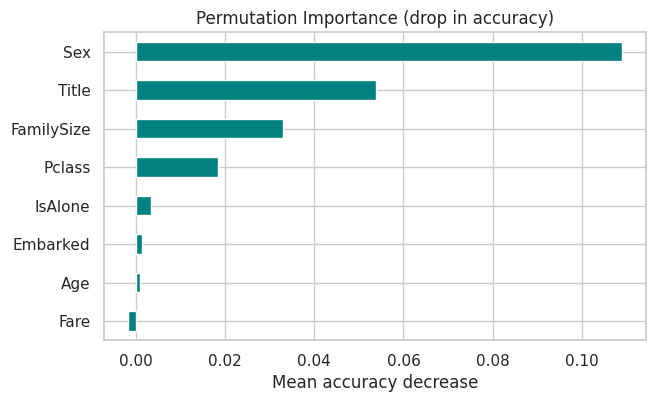

In [22]:
imp = permutation_importance(best_model, X_test, y_test, n_repeats=20,
                             random_state=RANDOM_STATE, scoring="accuracy")
importance = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()

importance.plot(kind="barh", figsize=(7, 4), color="teal")
plt.title("Permutation Importance (drop in accuracy)")
plt.xlabel("Mean accuracy decrease")
plt.show()

## 13. Save the Model for Deployment

In [23]:
joblib.dump(best_model, "../models/titanic_model.joblib")

metrics = {
    "model": best_name,
    "best_params": {k: (None if v is None else v) for k, v in searches[best_name].best_params_.items()},
    "cv_accuracy": round(float(searches[best_name].best_score_), 4),
    "test_accuracy": round(float(test_acc), 4),
    "test_roc_auc": round(float(test_auc), 4),
    "features": numeric_features + categorical_features,
}
with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
metrics

{'model': 'Random Forest',
 'best_params': {'model__max_depth': 5,
  'model__min_samples_split': 5,
  'model__n_estimators': 100},
 'cv_accuracy': 0.8287,
 'test_accuracy': 0.8268,
 'test_roc_auc': 0.8578,
 'features': ['Pclass',
  'Age',
  'Fare',
  'FamilySize',
  'IsAlone',
  'Sex',
  'Embarked',
  'Title']}

## 14. Try the Model on New Passengers

In [24]:
new_passengers = pd.DataFrame([
    {"Name": "Smith, Mr. John",        "Pclass": 3, "Sex": "male",   "Age": 22, "SibSp": 1, "Parch": 0, "Fare": 7.25,  "Embarked": "S"},
    {"Name": "Brown, Mrs. Anna",       "Pclass": 1, "Sex": "female", "Age": 35, "SibSp": 1, "Parch": 1, "Fare": 90.0,  "Embarked": "C"},
    {"Name": "Lee, Master. Tommy",     "Pclass": 2, "Sex": "male",   "Age": 6,  "SibSp": 1, "Parch": 1, "Fare": 30.0,  "Embarked": "S"},
])
new_passengers = add_features(new_passengers)[numeric_features + categorical_features]

new_passengers["Predicted"] = best_model.predict(new_passengers)
new_passengers["P(Survive)"] = best_model.predict_proba(new_passengers[numeric_features + categorical_features])[:, 1].round(3)
new_passengers

,Pclass,Age,Fare,FamilySize,IsAlone,Sex,Embarked,Title,Predicted,P(Survive)
0,3,22,7.25,2,0,male,S,Mr,0,0.138
1,1,35,90.00,3,0,female,C,Mrs,1,0.959
2,2,6,30.00,3,0,male,S,Master,1,0.605


## 15. Conclusion, Limitations & Future Work

**Key findings**
1. **Sex, ticket class and title** are the biggest drivers of survival: women, children and first-class passengers were far more likely to survive.
2. Simple **feature engineering** (`Title`, `FamilySize`, `IsAlone`) improved cross-validated accuracy for Logistic Regression from ~79.6% to ~82.3%.
3. Before tuning, the simple **Logistic Regression** (CV 82.3%) beat the default Random Forest (79.2%). After `GridSearchCV`, the **tuned Random Forest** reached the best CV accuracy (82.9%), so it was selected. Tuning mattered: shallow trees (`max_depth=5`) stopped the forest from overfitting.
4. **Final result on unseen test data:** ~82.7% accuracy and ROC-AUC ~0.86, versus ~80.4% for the tuned model on the raw features. The gain comes from feature engineering.

**Limitations**
- Only 891 rows; test set of 179 → accuracy estimates have roughly ±3% uncertainty.
- Recall for survivors is lower than for non-survivors (the model is more cautious about predicting "survived").
- `Cabin` (deck) and `Ticket` were dropped; they could add signal if engineered carefully.

**Future work:** engineer deck and ticket-group features, try Gradient Boosting / XGBoost, use threshold tuning to improve survivor recall, and submit predictions to the Kaggle leaderboard.